# PyTorch Computer Vision

## 0. Computer Vision libaries in PyTorch  
  
* `torchvision` - base domain library for PyTorch computer vision  
* `torchvision.datasets` - get datasets and data loading functions for computer vision here  
* `torchvision.models` - get pretrained computer vision models  
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML model  
* `torch.utils.data.Dataset` - base dataset class for PyTorch  
* `torch.utils.data.Dataloader` - creates a Python iterable over a dataset  
  
[Transforming and Augmenting Images](https://docs.pytorch.org/vision/0.21/transforms.html) <-- PyTorch Documentation

In [ ]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


## 1. Getting a dataset  
  
The dataset going to be used is FashionMNIST from `torchvision.datasets`

In [ ]:
# Setup training data
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # Do we want the training dataset?
    download=True, # Do we want to download it?
    transform=torchvision.transforms.ToTensor(), # How do we want to transform the data?
    target_transform=None # How do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False, # <-- We want the TEST data
    download=True,
    transform=ToTensor(),
    target_transform=None
)

Lets take a step back and analyze the `transform` part of the datasets function. A transform in computer vision transforms the images of the data into something standardized for the model. For example, you could have a transform that changes all images to 512x512 size.  

`transforms.Compose([  Transform Functions here... ])` - used to create transform objects that chain together a sequence of transform functions.   

For example:  
`transform = transforms.Compose([  
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])`  
Then you would apply it as so:  
`train_data = datasets.FashionMNIST(...transform=transform)`  
  
FashionMNIST is a basic dataset that is already uniform. All images are 28x28 in grayscale, meaning they are ready for use. `ToTensor()` is all that is needed to transform the dataset for training/testing.  
* However in more complex datasets, custom transform logic is vital.

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx # Gives dictionary of labels and their corresponding index
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
# Check the shape of the image
print(f"Image Shape: {image.shape} --> [colors_channels, height, width]")
print(f"Image Label: {class_names[label]}")

Image Shape: torch.Size([1, 28, 28]) --> [colors_channels, height, width]
Image Label: Ankle boot


Grayscale only has one color channel as something is either white or black. A value like 0 would be pure black and 1 would be pure white, inbetween is gray.

### 1.2 Visualizing the data

Image Shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

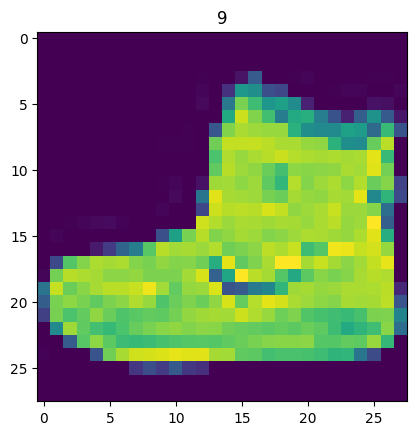

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image Shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

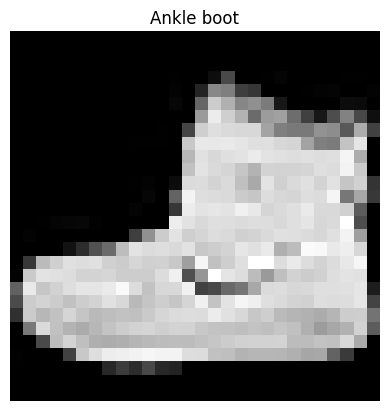

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

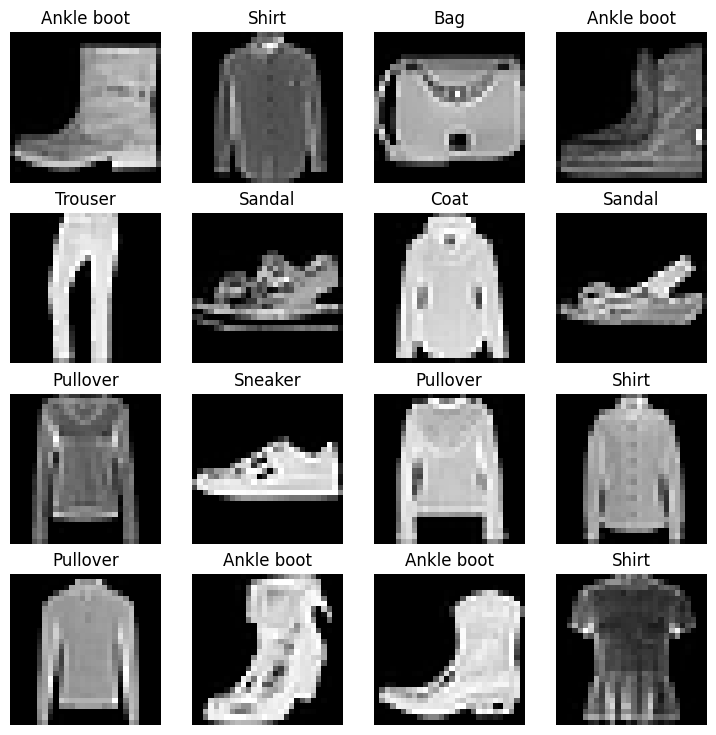

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader  
  
Right now the data is in the form of PyTorch Datasets.  
  
DataLoader turns the dataset into a Python iterable.  
  
More specifically, the data needs to be turned into batches (or mini-batches).  
  
Why is this done?  
1. It is more computationally efficient, as in, the computing hardware may not be able to look (store in memory) at 60000 images in one hit. So you can break it down into 32 images at a time (batch size of 32).  
2. It gives the neural network more chances to update its gradients per epoch.  


In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset=train_data, # Which dataset to be used
                              batch_size=BATCH_SIZE, # batch size (how many images)
                              shuffle=True) # shuffling up the data (adding randomness)

test_dataloader = DataLoader(dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b41438e9650>,
 <torch.utils.data.dataloader.DataLoader at 0x7b41438a6f90>)

In [ ]:
# Let's check it out
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7b41438e9650>, <torch.utils.data.dataloader.DataLoader object at 0x7b41438a6f90>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batches of 32...


In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader)) # Changing it to an interable then getting the next entry
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 6, label size: torch.Size([])


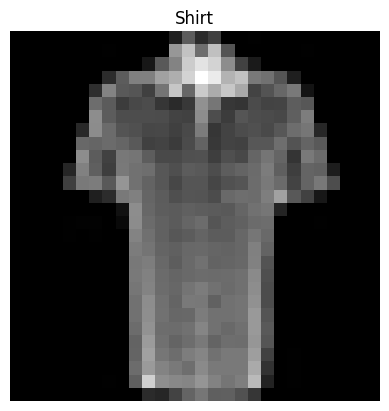

In [ ]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## 3. Model 0: Build a baseline model

When starting to build a series of machine learning modelling experiments, it's best practice to start w/ a baseline model.  
  
A baseline model is a simple model you will try and improve upon w/ subsequent models/experiments.  
  
In other words: start simply and add complexity when necessary.

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happend
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [ ]:
from torch import nn
class FashionMISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # <-- Flatten the data first
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units), # <-- Input layer
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape) # <-- Output layer
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

# Setup model w/ input parameters
model_0 = FashionMISTModelV0(
    input_shape = 784, # <-- this is 28*28, the output of flattened data
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
).to("cpu") # <--  Starting with cpu as device for now

model_0

FashionMISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
# Lets test a forward pass
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x) # outputs 10 different logits for the 10 classes

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

### 3.1 Setup loss, optimizer, and evaluation metrics  
  
* Loss function - since the data is mult-class, the loss function will be `nn.CrossEntropyLoss()`  
* Optimizer - the optimizer `torch.optim.SGD()` (stochastic gradient descent)  
* Evalatuation Metric - since it is a classification problem, let's use accuracy as the evaluation metric

In [ ]:
!pip install -q torchmetrics

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [ ]:
# Defining Accuracy Function
import torchmetrics
from torchmetrics.classification import Accuracy

accuracy = Accuracy(task="multiclass", num_classes=10).to("cpu")

In [ ]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

### 3.2 Creating a function to time experiments  
  
Machine learning is very experimental.  
  
Two of the main things you'll often want to track are:  
1. Model's performance (loss and accuracy values, etc)  
2. How fast it runs

In [ ]:
from timeit import default_timer as timer

def print_train_time(start: float,
                      end: float,
                      device: torch.device = None):
  """Prints difference between start and end time."""

  total_time = end - start
  print(f"Train Time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
# For example...
start_time = timer() # starts timer
# ... model code ...
end_time = timer() # ends timer
print_train_time(start=start_time, end=end_time, device="cpu")

Train Time on cpu: 0.000 seconds


6.256500000745291e-05

So basically it sees how long all of the model code takes to run.

### 3.3 Creating a training loop and training model on batches of data  
  
1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*.
4. Print out what's happening.
5. Time it all.

In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm # auto just means it adjusts progress bars to the media being coding on (ie: Google Colab)

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_cpu = timer() # starts the timer

# Set number of epochs (keeping it small for faster training time) - Remember: this is the baseline, experimental model
epochs = 3

# Create training loop
for epoch in tqdm(range(epochs)): # including tqdm for progress bar
  print(f"Epoch: {epoch}\n------")
  ### Training
  train_loss = 0
  # Add a loop to loop through the training batches
  for batch, (image, label) in enumerate(train_dataloader): # enumerate creates a batch counter. Useful for printing later
    model_0.train()
    # 1. Forward Pass
    y_pred = model_0(image)

    # 2. Calculate the loss (per batch)
    loss = loss_fn(y_pred, label)
    train_loss += loss # accumulate train loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Print out what's happening
    if batch % 400 == 0: # <-- batch counter used from enumerate earlier
      print(f"Looked at {batch * len(image)}/{len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for image_test, label_test in test_dataloader:
      # 1. Forward Pass
      test_pred = model_0(image_test)

      # 2. Calculate the loss (accumulatively)
      test_loss += loss_fn(test_pred, label_test).item() # <-- .item() is used cause needs to not be a tensor or else it will break

      # 3. Calculate accuracy
      test_acc += accuracy(test_pred.argmax(dim=1), label_test).item() # <-- .item() cause it can't be a tensor

  # This is why I used .item(). Tensors cannot be modified under inference_mode() context, so adding .item() makes it a python float.
  # Calculate the test loss average per batch
  test_loss /= len(test_dataloader)

  # Calculate the test acc average per batch
  test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc*100:.4f}")

# Calculate the training time
train_time_end_cpu = timer() # ends the timer
total_train_time_model_0 = print_train_time(start=train_time_start_cpu,
                                            end=train_time_end_cpu,
                                            device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5095, Test acc: 82.0387
Epoch: 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4763 | Test loss: 0.4799, Test acc: 83.1969
Epoch: 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4550 | Test loss: 0.4766, Test acc: 83.4265
Train Time on cpu: 34.433 seconds


## 4. Make predictions and get Model 0 results

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for image_test, label_test in data_loader:
      # Make predictions (forward pass)
      y_pred = model(image_test)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, label_test).item()
      acc += accuracy(y_pred.argmax(dim=1), label_test).item()

    # Scale the loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)
    acc = acc * 100

  return {"model_name": model.__class__.__name__, # only works when model was created w/ a class
          "model_loss": loss,
          "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy=accuracy)

model_0_results

{'model_name': 'FashionMISTModelV0',
 'model_loss': 0.4766388962063165,
 'model_acc': 83.42651757188499}

Lets import modules needed once again so the notebook can be run from this cell on, for convenience.

## 5. Setup device agnostic-code (for using a GPU if there is one)

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

In [ ]:
class FashionMISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(), # Flatten the data into a single vector
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units), # <-- Input layer
        nn.ReLU(), # <-- Adding non-linearity
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape), # <-- Output layer
        nn.ReLU() # <-- Adding non-linearity
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
# Create an instance of model_1
torch.manual_seed(42)
model_1 = FashionMISTModelV1(
    input_shape=784,
    hidden_units=15,
    output_shape=len(class_names)
).to(device)

next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer, and evaluation metrics

In [ ]:
# Move accuracy function to correct device:
accuracy = Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss() # measures how wrong the model is
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1) # tries to update the model's parameters to reduce the loss

### 6.2 Functionizing training and evaluation/testing loops

Lets create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`



In [ ]:
def train_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy,
    device: torch.device = device):

  """ Performs training step with model trying to learn on dataloader."""

  train_loss, train_acc = 0, 0

  # Put model into training mode
  model.train()

  # Add a loop to loop through the training batches
  for batch, (image, label) in enumerate(dataloader):

    # Put data on target device
    image, label = image.to(device), label.to(device)

    # 1. Forward Pass
    y_pred = model(image)

    # 2. Calculate the loss (per batch)
    loss = loss_fn(y_pred, label)
    train_loss += loss.item() # accumulate train loss
    train_acc += accuracy(y_pred.argmax(dim=1), label).item() # accumulate train accuracy

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Divide total train loss by length of train dataloader
  train_loss /= len(dataloader)
  train_acc /= len(dataloader)

  # Print out whats happening
  print(f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.3f}")


In [ ]:
def test_step(
    model: torch.nn.Module,
    dataloader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy,
    device: torch.device = device):

  """Performs a testing loop step on model going over dataloader."""
  test_loss, test_acc = 0, 0

  # Put model into eval mode
  model.eval()

  with torch.inference_mode():
    for image_test, label_test in dataloader:
      image_test, label_test = image_test.to(device), label_test.to(device)

      # 1. Forward Pass (outputs raw logits)
      test_pred = model(image_test)

      # 2. Calculate the loss (accumulatively)
      test_loss += loss_fn(test_pred, label_test).item() # <-- .item() is used cause needs to not be a tensor or else it will break

      # 3. Calculate accuracy
      test_acc += accuracy(test_pred.argmax(dim=1), label_test).item() # <-- .item() cause it can't be a tensor

    # Calculate the averages
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)

    # Print out whats happening
    print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.3f}")

In [ ]:
torch.manual_seed(42)

# Set epochs and start timer
epochs = 3
train_time_start_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(
      model=model_1,
      dataloader=train_dataloader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      accuracy=accuracy,
      device=device)

  test_step(
      model=model_1,
      dataloader=test_dataloader,
      loss_fn=loss_fn,
      accuracy=accuracy,
      device=device)

train_time_end_gpu = timer()

total_train_time_model_1 = print_train_time(
    start=train_time_start_gpu,
    end=train_time_end_gpu,
    device=str(next(model_1.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.948 | Train Acc: 67.568
Test Loss: 0.712 | Test Acc: 73.842
Epoch: 1
-------
Train Loss: 0.674 | Train Acc: 75.048
Test Loss: 0.685 | Test Acc: 75.629
Epoch: 2
-------
Train Loss: 0.641 | Train Acc: 76.158
Test Loss: 0.664 | Test Acc: 75.429
Train Time on cuda:0: 38.060 seconds


**Note:** Sometimes, depending on the data/hardware the model might train faster on the CPU than GPU.

Why is this?  
1. It could be that the overhead for copying data/model to and from the GPU outweighs the compute benefits offered by the GPU.
2. The hardware being used has a better CPU in terms compute capability than the GPU (not likely).  
  
GPUs preform better on larger models and datasets.

In [ ]:
print(f"Model 0 Train Time: {total_train_time_model_0}")
print(f"Model 1 Train Time: {total_train_time_model_1}")

Model 0 Train Time: 34.43325603500034
Model 1 Train Time: 38.06019110699981


In [ ]:
# Updated eval_model() function with device agnostic code
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy,
               device: torch.device = device):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for image_test, label_test in data_loader:
      # Make device agnostic code for data
      image_test, label_test = image_test.to(device), label_test.to(device)

      # Make predictions (forward pass)
      y_pred = model(image_test)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, label_test).item()
      acc += accuracy(y_pred.argmax(dim=1), label_test).item()

    # Scale the loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)
    acc = acc * 100

  return {"model_name": model.__class__.__name__, # only works when model was created w/ a class
          "model_loss": loss,
          "model_acc": acc}

# Calculate model 1 results on test dataset
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy=accuracy
)
model_1_results

{'model_name': 'FashionMISTModelV1',
 'model_loss': 0.6644326757889586,
 'model_acc': 75.42931309904152}

In [ ]:
model_0_results

{'model_name': 'FashionMISTModelV0',
 'model_loss': 0.4766388962063165,
 'model_acc': 83.42651757188499}

### **CNN vs Linear Model**

Lets analyze what makes a CNN different to the linear model just built.  

The previous model treated the image tensor as one big tensor of numbers and each linear layer performed the operation:  
`output = input * weight + bias`  
**Note**: It treated every number in the tensor equally so it had no structure of an image, just numbers.  
  
CNNs do something different. They use kernels or "filters" to analyze an image tensor by iterating through an area, such as 3x3, and sliding across the image.
  * The kernel treats nearby pixels more importantly than far off ones, making it keep the image structure  
  
CNNs output a new tensor called a "feature map", which shows the results of the filter, to pass to the next layer.

  
Pooling is used in CNNs to reduce image data while retaining important information. This is vital for reducing compute power and increasing efficiency.  
They do this by taking a section, such as a 2x2 grid, and only retaining the highest value of said section.
* This gets rid of unnecessary values that could slow down performance while keeping the values that truly matter.

## Model 2: Building a Convolutional Neural Network (CNN)

CNN's are also known as ConvNets.  
  
CNN's are known for the their capabilities to find patterns in visual data.  
  
  
[CNN Explainer](https://poloclub.github.io/cnn-explainer/) <-- Good Website for learning about CNNs  

In [ ]:
# Create a CNN
class FashionMISTModelV2(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  model from CNN explainer website.
  """

  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # Create a conv layer
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3, # the size of the filter (e.g., 3x3)
                  stride=1, # the amount of pixels the filter slides over at a time
                  padding=1), # adds extra pixels around the border of the image to preserve image data
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # <-- pooling layer
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 7 * 7, # there's a trick to calculating this...
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier_layer(x)
    return x

In [ ]:
image.shape

torch.Size([32, 1, 28, 28])

In [ ]:
torch.manual_seed(42)
model_2 = FashionMISTModelV2(
    input_shape=1, # <-- Color channels of images
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

### 7.1 Stepping through `nn.Conv2d()`

In [ ]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [ ]:
torch.manual_seed(42)
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3, # same as color channels
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0)

# Pass the data through the convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [ ]:
# Print out original image shape
print(f"Test image original shape: {test_image.shape}")

# Create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image)
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() & max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Shape after going through conv_layer(): torch.Size([10, 62, 62])
Shape after going through conv_layer() & max_pool_layer(): torch.Size([10, 31, 31])


In [ ]:
torch.manual_seed(42)
# Create a random tensor w/ a similar number of dimensions to the images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"\nRandom tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)

print(f"\nMax pool tensor:\n {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")


Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
 tensor([[[[0.3367]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])


In [ ]:
torch.manual_seed(42)

# Create random image
random_image = torch.randn(size=(1, 28, 28))
print(f"Original Image Shape: {random_image.shape}")

conv_block_1 = nn.Sequential(
        # Create a conv layer
        nn.Conv2d(in_channels=1,
                  out_channels=10,
                  kernel_size=3, # the size of the filter (e.g., 3x3)
                  stride=1, # the amount of pixels the filter slides over at a time
                  padding=1), # adds extra pixels around the border of the image to preserve image data
        nn.ReLU(),
        nn.Conv2d(in_channels=10,
                  out_channels=10,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2) # <-- pooling layer
    )

conv_block_1_image = conv_block_1(random_image)
print(f"Image shape after conv_block_1() layer: {conv_block_1_image.shape}")

conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=10,
                  out_channels=10,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=10,
                  out_channels=10,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

conv_block_2_image = conv_block_2(conv_block_1_image)
print(f"Image shape after conv_block_2() layer: {conv_block_2_image.shape}")

flatten_layer = nn.Flatten()

flattened_image = flatten_layer(conv_block_2_image)
print(f"Image shape after flatten layer: {flattened_image.shape}")

Original Image Shape: torch.Size([1, 28, 28])
Image shape after conv_block_1() layer: torch.Size([10, 14, 14])
Image shape after conv_block_2() layer: torch.Size([10, 7, 7])
Image shape after flatten layer: torch.Size([10, 49])


This example code, where I defined the layers individually, works a bit different from the CNN model.  
The CNN model expects batches while the example code does not, meaning it expects a 4D tensor while the example code expects a 3D tensor.   
This is why if an individual image is ran through the model (see below) then you must add an extra dimension with `.unsqueeze(0)`

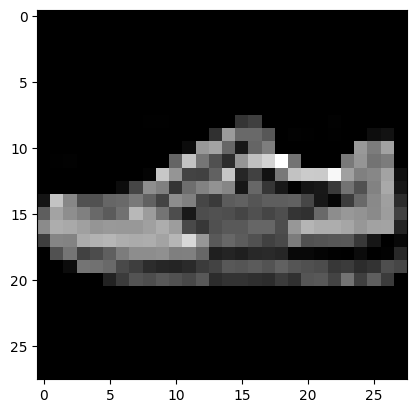

In [ ]:
# Lets get a test image to run through the model
shoe_image = image[5]
plt.imshow(shoe_image.squeeze(), cmap="grey")

In [ ]:
print(shoe_image.shape)
print(shoe_image.unsqueeze(dim=1).shape)

torch.Size([1, 28, 28])
torch.Size([1, 1, 28, 28])


In [ ]:
# Pass image through model
model_2(shoe_image.unsqueeze(0).to(device))

tensor([[ 0.0320, -0.0611,  0.0504, -0.0238, -0.0171,  0.0162, -0.0073, -0.0065,
          0.0263,  0.0106]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss function and optimizer for `model_2`

In [ ]:
# Setup Loss Function and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

In [ ]:
# Setup Accuracy Function
from torchmetrics import Accuracy

accuracy = Accuracy(task="Multiclass", num_classes=10).to(device)

### 7.4 Training and Testing `model_2`

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Set epochs and start timer
epochs = 3
train_timer_start_model_2 = timer()

# Train and Test model
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(
      model=model_2,
      dataloader=train_dataloader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      accuracy=accuracy,
      device=device
  )
  test_step(
      model=model_2,
      dataloader=test_dataloader,
      loss_fn=loss_fn,
      accuracy=accuracy,
      device=device
  )

# Measure the time
train_timer_end_model_2 = timer()
model_2_train_time = print_train_time(
    start=train_timer_start_model_2,
    end=train_timer_end_model_2,
    device=device
)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train Loss: 0.594 | Train Acc: 78.462
Test Loss: 0.396 | Test Acc: 85.923
Epoch: 1
-------
Train Loss: 0.361 | Train Acc: 87.005
Test Loss: 0.351 | Test Acc: 87.011
Epoch: 2
-------
Train Loss: 0.326 | Train Acc: 88.207
Test Loss: 0.323 | Test Acc: 87.909
Train Time on cuda: 42.980 seconds


In [ ]:
# Get model_2 results
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy=accuracy,
    device=device
)

model_2_results

{'model_name': 'FashionMISTModelV2',
 'model_loss': 0.32348061499361414,
 'model_acc': 87.90934504792332}

## 8. Compare model results and training time

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMISTModelV0,0.476639,83.426518
1,FashionMISTModelV1,0.664433,75.429313
2,FashionMISTModelV2,0.323481,87.909345


In [ ]:
# Add training time to results comparison
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    model_2_train_time]

In [ ]:
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMISTModelV0,0.476639,83.426518,34.433256
1,FashionMISTModelV1,0.664433,75.429313,38.060191
2,FashionMISTModelV2,0.323481,87.909345,42.979774


Text(0, 0.5, 'model')

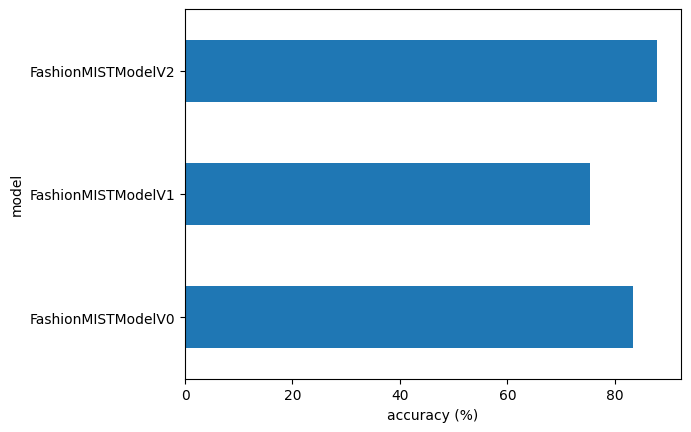

In [ ]:
# Visualize the model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

## 9. Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device=device):
  pred_probs = []

  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass (model outputs raw logits)
      pred_logit = model(sample)

      # Get prediction probability (logit -> prediction probability)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      # Get pred_prob off the GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs ot turn list into a tensor
  return torch.stack(pred_probs)

In [ ]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [ ]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

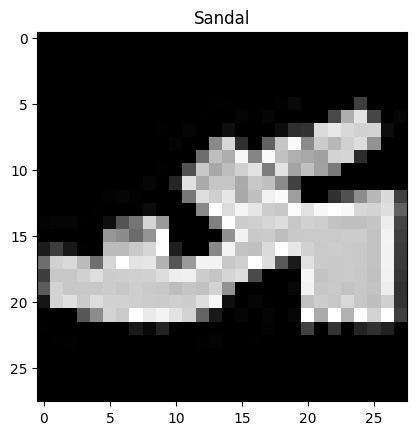

In [ ]:
plt.imshow(test_samples[0].squeeze(0), cmap="gray")
plt.title(class_names[test_labels[0]])

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# View first two prediction probabilities
pred_probs[:2]

tensor([[9.7008e-08, 6.2720e-09, 6.5783e-08, 3.1686e-08, 6.9743e-09, 9.9983e-01,
         4.9662e-08, 8.7422e-06, 1.1986e-05, 1.4420e-04],
        [3.1187e-02, 8.1903e-01, 4.6721e-04, 4.4100e-02, 3.2507e-02, 2.8114e-05,
         7.2590e-02, 3.0689e-05, 3.5380e-05, 2.1704e-05]])

In [ ]:
# Convert prediction probabilties to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [ ]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

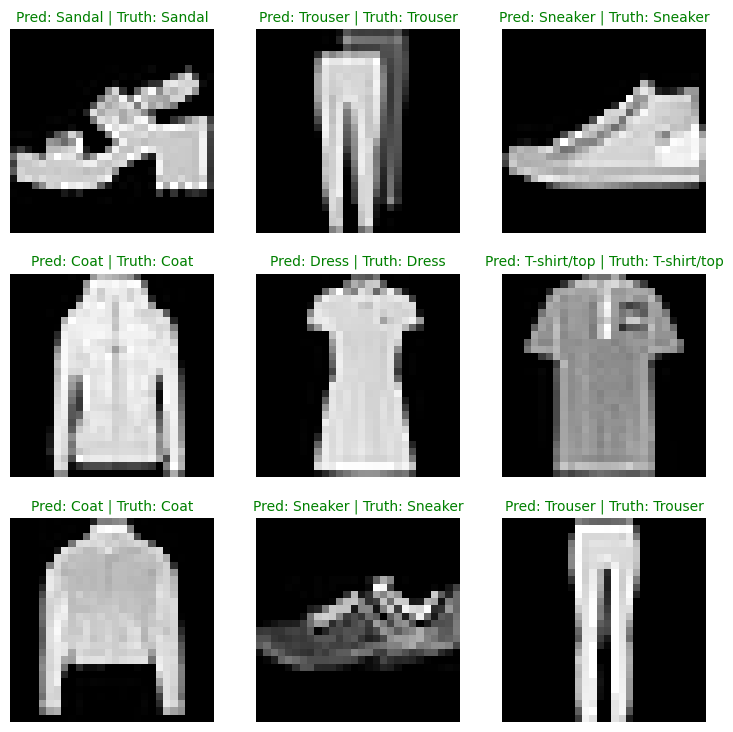

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction (in test form, e.g "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form)
  truth_label = class_names[test_labels[i]]

  # Create a title for the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g") # green text if pred is correct
  else:
    plt.title(title_text, fontsize=10, c="r") # red text if pred is incorrect

  plt.axis(False)